In [1]:
import os
from google.cloud import bigquery

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import ROOT_DIR


CLIENT = bigquery.Client.from_service_account_json(os.path.join(ROOT_DIR, 'bq_credentials.json'))

def peek_df(df, nrows=5):
  print(df.shape)
  display(df.head(nrows))

# Opportunity Persistence Analysis

---

## Distribution of Opportunities

In [2]:
query = """
    SELECT
        triangle_key,
        COUNT(*) AS frequency
    FROM `forward-alchemy-424420-g0.cs6242.vw_unique_opportunity_instances`
    GROUP BY 1
"""

opp_frequency = CLIENT.query(query).to_dataframe()

peek_df(opp_frequency)

/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(1161, 2)


,triangle_key,frequency
0,1INCH|BTC|BUSD,3
1,1INCH|BUSD|USDT,4
2,AAVE|BNB|BTC,7
3,AAVE|BNB|BUSD,4
4,AAVE|BNB|ETH,7


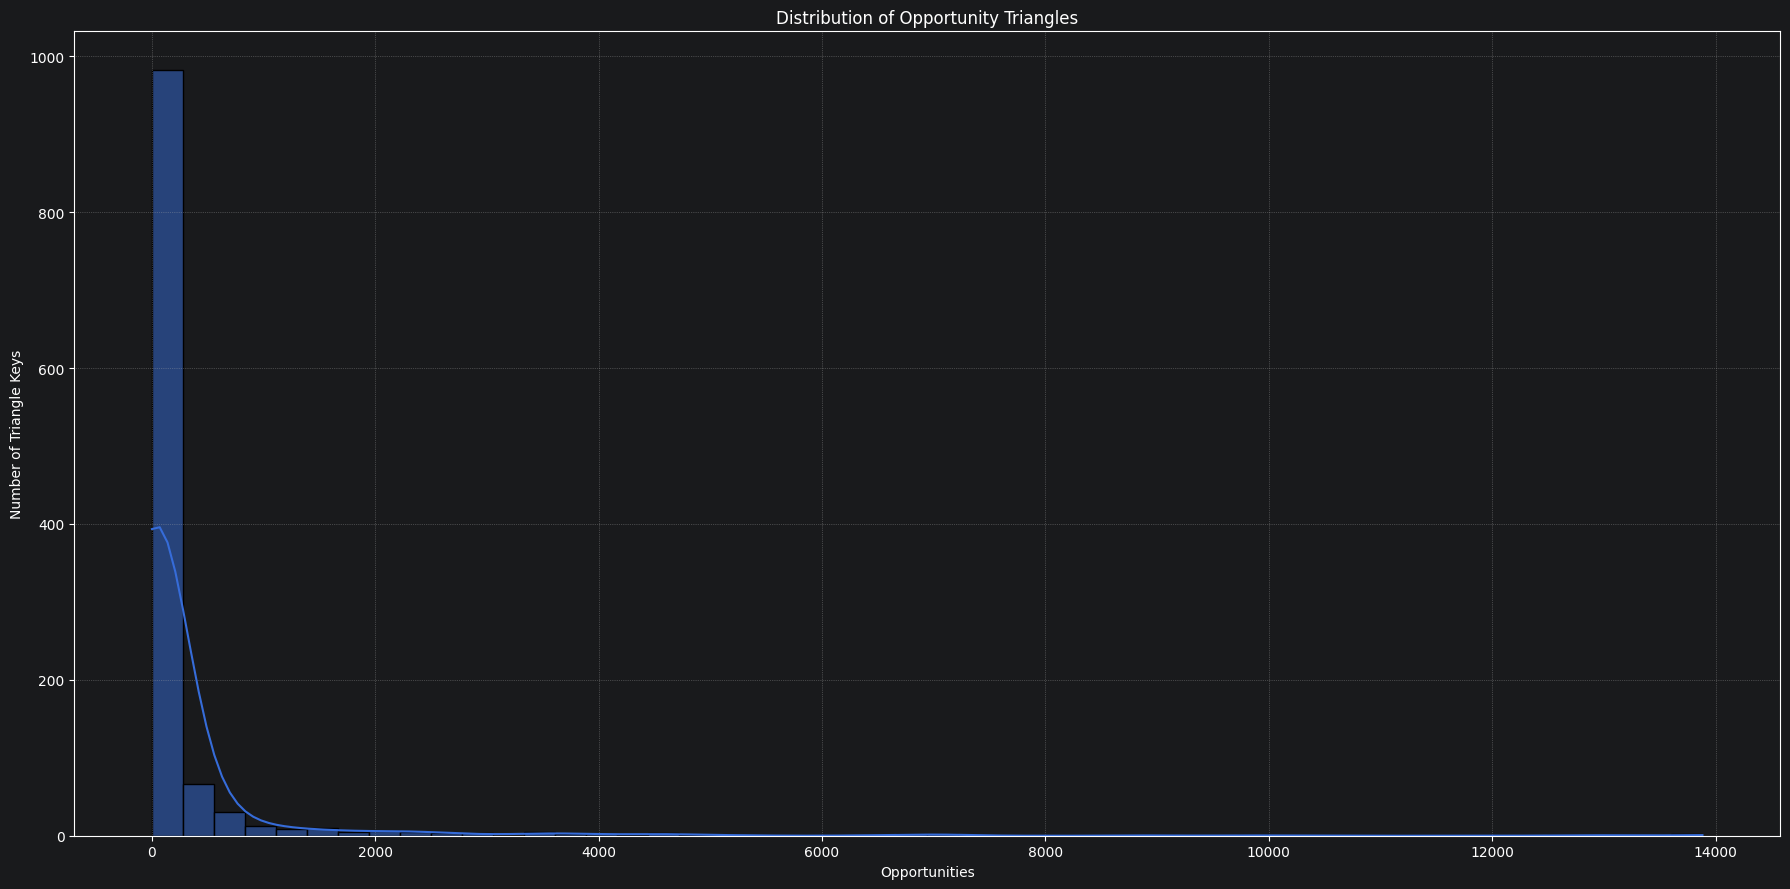

In [3]:
NUM_BINS = 50

plt.figure(figsize=(18, 9))

sns.histplot(opp_frequency['frequency'], bins=NUM_BINS, edgecolor='black', kde=True)

plt.title('Distribution of Opportunity Triangles')
plt.xlabel('Opportunities')
plt.ylabel('Number of Triangle Keys')

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Number of Opportunities Across Time

Measured as the count of opportunities for a given triangle key. This helps assess high-opportunity timeframes.

In [8]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_unique_opportunity_frequency_by_date`"

opp_date_frequencies = CLIENT.query(query).to_dataframe()
opp_date_frequencies['date'] = pd.to_datetime(opp_date_frequencies['date'], format='mixed', utc=True).dt.date

peek_df(opp_date_frequencies)

(307105, 3)


,date,frequency,granularity
0,2021-05-09,271,DAY
1,2021-05-06,243,DAY
2,2021-06-22,403,DAY
3,2019-08-12,120,DAY
4,2020-05-25,541,DAY


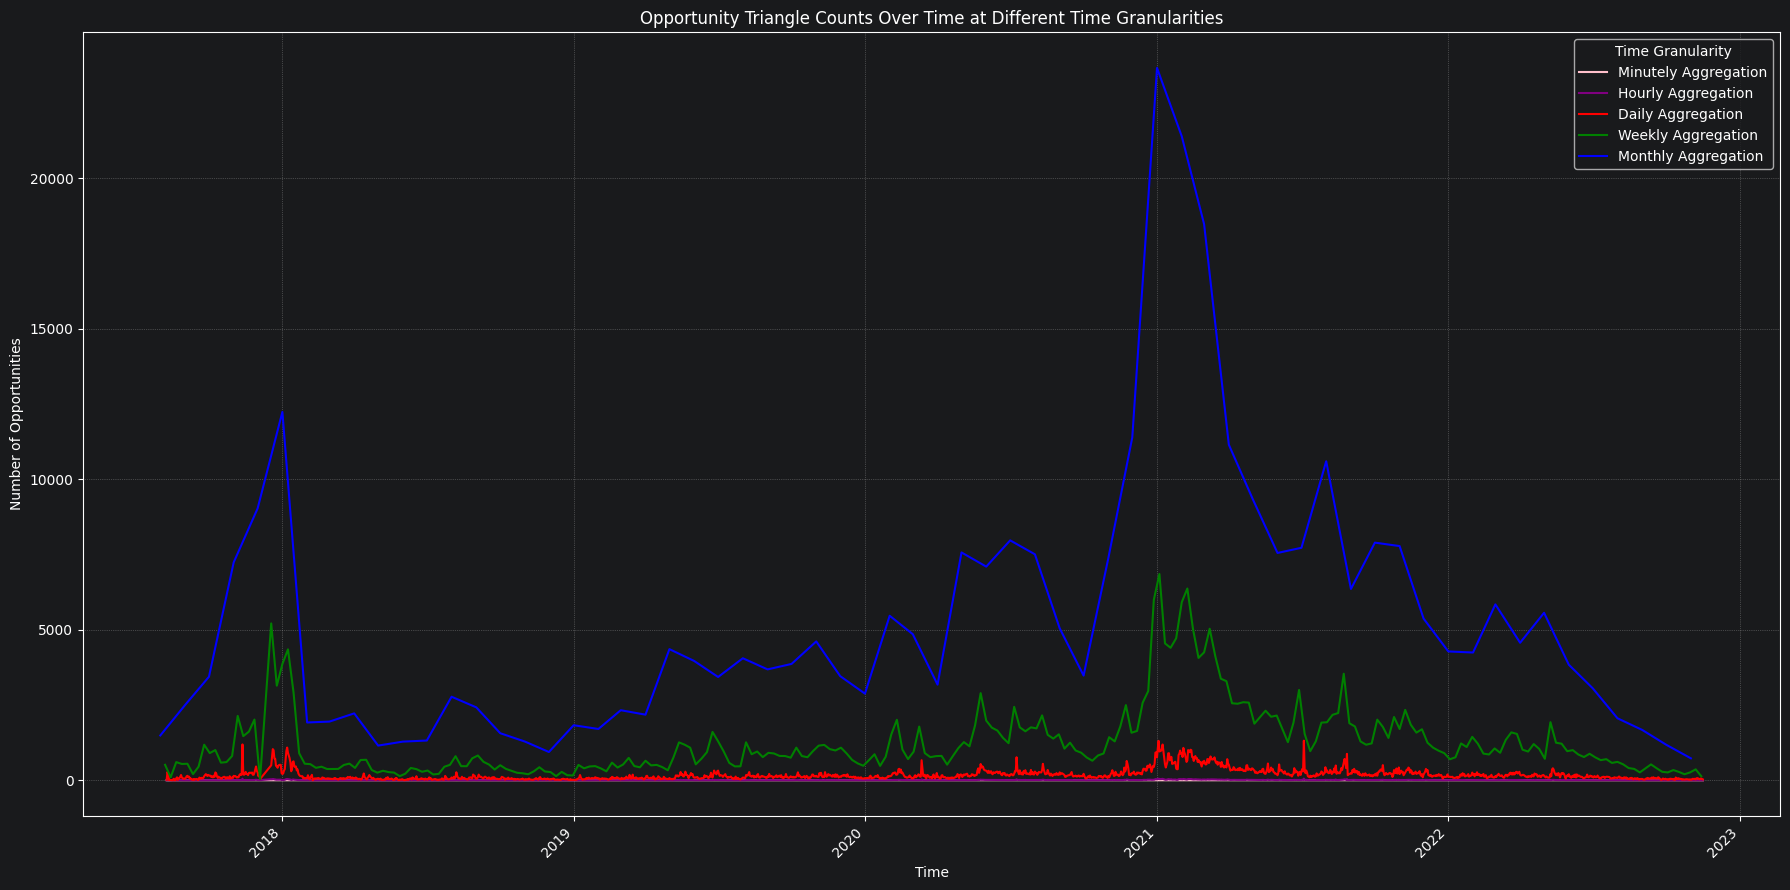

In [9]:
plt.figure(figsize=(18, 9))

# Minute counts
minute_data = opp_date_frequencies[opp_date_frequencies['granularity'] == 'MINUTE']
sns.lineplot(x='date', y='frequency', data=minute_data, label='Minutely Aggregation', color='pink')

# Hourly counts
hour_data = opp_date_frequencies[opp_date_frequencies['granularity'] == 'HOUR']
sns.lineplot(x='date', y='frequency', data=hour_data, label='Hourly Aggregation', color='purple')

# Daily counts
day_data = opp_date_frequencies[opp_date_frequencies['granularity'] == 'DAY']
sns.lineplot(x='date', y='frequency', data=day_data, label='Daily Aggregation', color='red')

# Weekly counts
week_data = opp_date_frequencies[opp_date_frequencies['granularity'] == 'WEEK']
sns.lineplot(x='date', y='frequency', data=week_data, label='Weekly Aggregation', color='green')

# Monthly counts
month_data = opp_date_frequencies[opp_date_frequencies['granularity'] == 'MONTH']
sns.lineplot(x='date', y='frequency', data=month_data, label='Monthly Aggregation', color='blue')

plt.title('Opportunity Triangle Counts Over Time at Different Time Granularities')
plt.xlabel('Time')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Opportunities')

plt.legend(title='Time Granularity')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Opportunity Gap Analysis

Measured as the difference between two sequential appearances of a triangle key. This identifies the duration before an opportunity reappears, and may help assess patterns in these gaps.

In [10]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_unique_opportunity_avg_gaps_by_date`"

opp_avg_gaps_by_date = CLIENT.query(query).to_dataframe()
opp_avg_gaps_by_date['date'] = pd.to_datetime(opp_avg_gaps_by_date['date'], format='mixed', utc=True).dt.date

peek_df(opp_avg_gaps_by_date)

/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(306450, 3)


,date,avg_minutes_diff,granularity
0,2017-08-01,47.408081,MONTH
1,2017-08-07,11.896887,WEEK
2,2017-08-09,16.411765,DAY
3,2017-08-09,13.000000,HOUR
4,2017-08-09,13.000000,MINUTE


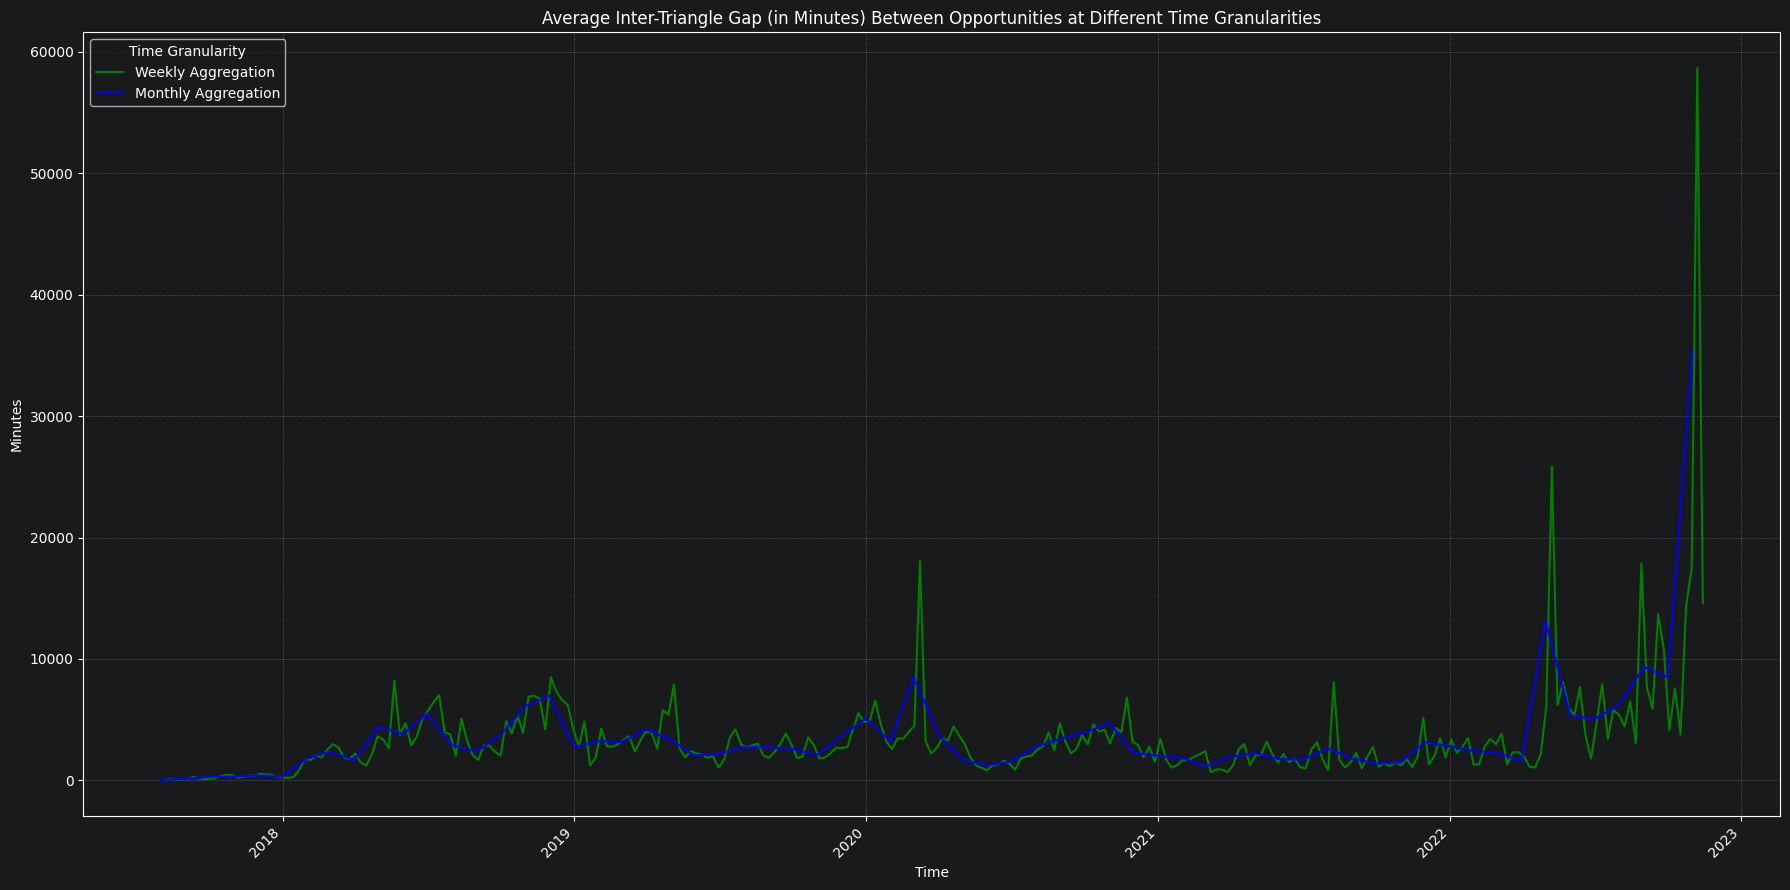

In [11]:
plt.figure(figsize=(18, 9))

# Minute
minute_data = opp_avg_gaps_by_date[opp_avg_gaps_by_date['granularity'] == 'MINUTE']
#sns.lineplot(x='date', y='avg_minutes_diff', data=minute_data, label='Minutely Aggregation', color='pink')

# Hourly
hour_data = opp_avg_gaps_by_date[opp_avg_gaps_by_date['granularity'] == 'HOUR']
#sns.lineplot(x='date', y='avg_minutes_diff', data=hour_data, label='Hourly Aggregation', color='purple')

# Daily
day_data = opp_avg_gaps_by_date[opp_avg_gaps_by_date['granularity'] == 'DAY']
#sns.lineplot(x='date', y='avg_minutes_diff', data=day_data, label='Daily Aggregation', color='red')

# Weekly
week_data = opp_avg_gaps_by_date[opp_avg_gaps_by_date['granularity'] == 'WEEK']
sns.lineplot(x='date', y='avg_minutes_diff', data=week_data, label='Weekly Aggregation', color='green')

# Monthly
month_data = opp_avg_gaps_by_date[opp_avg_gaps_by_date['granularity'] == 'MONTH']
sns.lineplot(x='date', y='avg_minutes_diff', data=month_data, label='Monthly Aggregation', color='blue')

plt.title('Average Inter-Triangle Gap (in Minutes) Between Opportunities at Different Time Granularities')
plt.xlabel('Time')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Minutes')

plt.legend(title='Time Granularity')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Lifetime of Opportunity Triangles

Measured as the difference between the last time and the first time an opportunity triangle appeared. This quantifies (to an extent) for how long a given triangle key has existed.

There is a limitation in that the triangle key may later again reappear, and we simply haven't captured that data, thus its persistence is cut short.

Additionally, do not mistake this for persistence or frequency of appearance. There could be large gaps of non-existence between a triangle key's earliest and latest appearance.

In [12]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_unique_opportunity_lifetimes`"

opp_lifetimes = CLIENT.query(query).to_dataframe()
opp_lifetimes['earliest_appearance'] = pd.to_datetime(opp_lifetimes['earliest_appearance'])
opp_lifetimes['latest_appearance'] = pd.to_datetime(opp_lifetimes['latest_appearance'])

peek_df(opp_lifetimes)

/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(1161, 9)


,triangle_key,currencies,earliest_appearance,latest_appearance,lifetime_minutes,lifetime_hours,lifetime_days,lifetime_weeks,lifetime_months
0,1INCH|BTC|BUSD,"[BTC, 1INCH, BUSD]",2021-02-23 20:28:00+00:00,2021-04-23 19:19:00+00:00,84891,1414.850000,58.952083,8.421726,1.965069
1,1INCH|BUSD|USDT,"[USDT, 1INCH, BUSD]",2021-02-23 20:28:00+00:00,2021-02-24 04:30:00+00:00,482,8.033333,0.334722,0.047817,0.011157
2,AAVE|BNB|BTC,"[BNB, BTC, AAVE]",2020-10-23 18:54:00+00:00,2021-01-26 12:58:00+00:00,136444,2274.066667,94.752778,13.536111,3.158426
3,AAVE|BNB|BUSD,"[BUSD, BNB, AAVE]",2020-10-23 17:01:00+00:00,2021-03-04 08:49:00+00:00,189588,3159.800000,131.658333,18.808333,4.388611
4,AAVE|BNB|ETH,"[BNB, ETH, AAVE]",2020-10-15 06:56:00+00:00,2021-05-27 23:21:00+00:00,323545,5392.416667,224.684028,32.097718,7.489468


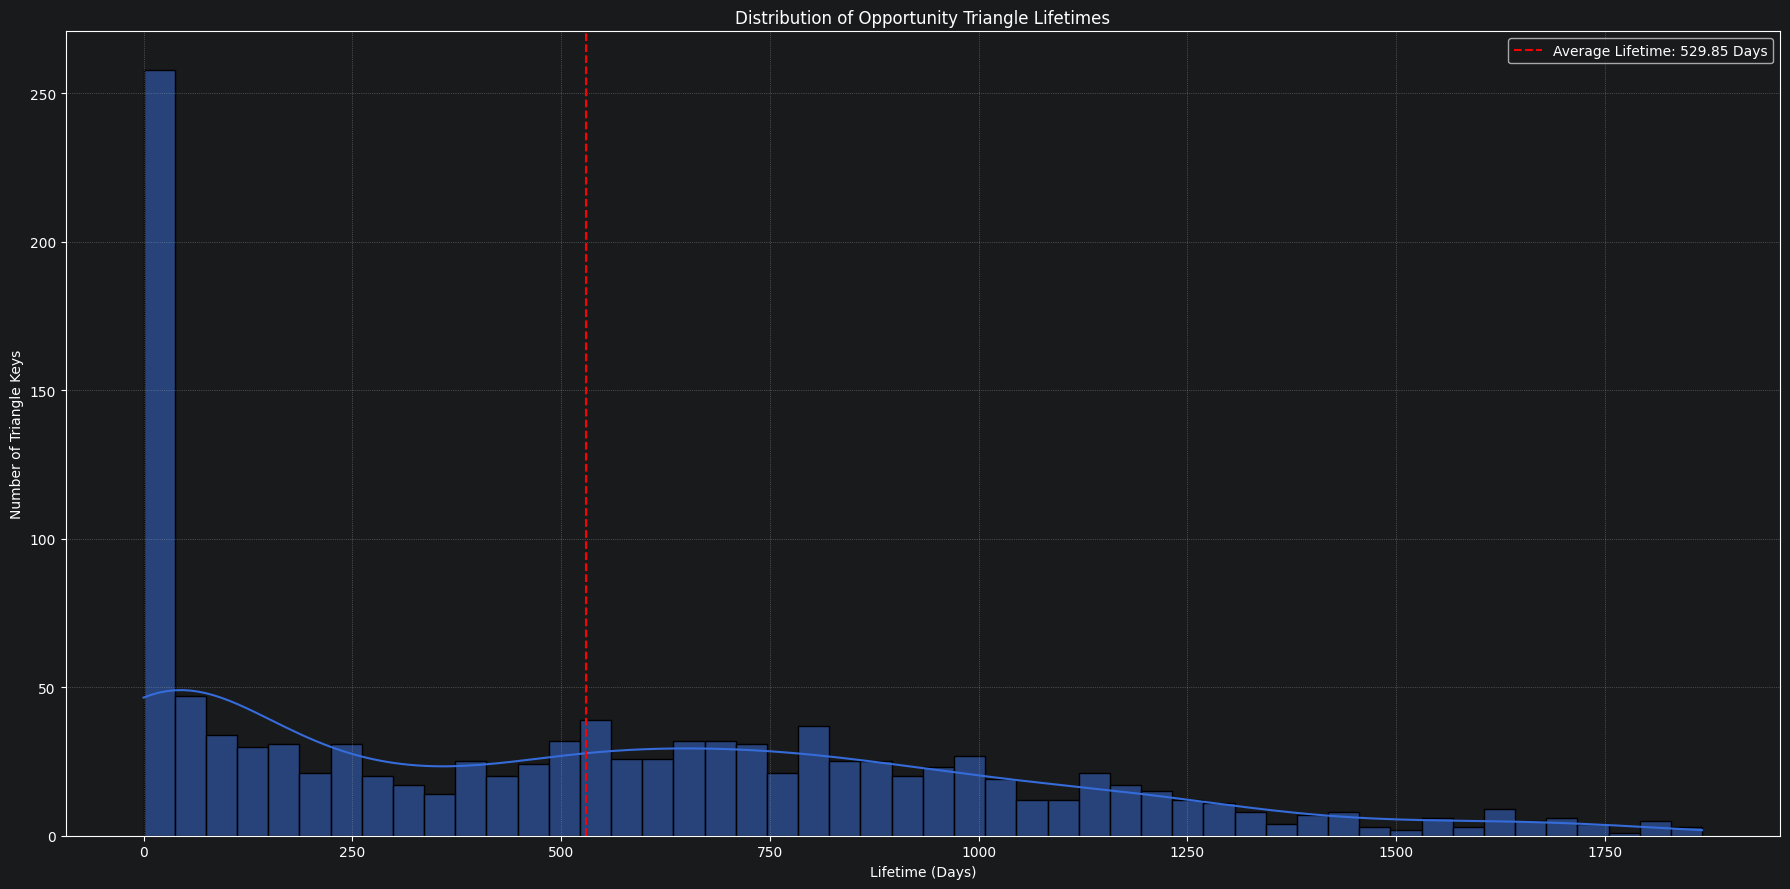

In [13]:
plt.figure(figsize=(18, 9))

sns.histplot(opp_lifetimes['lifetime_days'], bins=50, edgecolor='black', kde=True)

avg_lifetime = opp_lifetimes['lifetime_days'].mean()
plt.axvline(avg_lifetime, color='red', linestyle='--', label=f'Average Lifetime: {avg_lifetime:.2f} Days')

plt.title('Distribution of Opportunity Triangle Lifetimes')
plt.xlabel('Lifetime (Days)')
plt.ylabel('Number of Triangle Keys')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Persistence Across Time
### NOTE: Can ignore this one. It's obvious that lifetimes will decrease over time by definition, since the earliest_appearance date window narrows but the latest_appearance date remains constant. I mainly wanted to plot this out to see if there was a date far in the past that had abnormally low/high lifetimes.

In [14]:
opp_lifetimes['weekly_start'] = opp_lifetimes['earliest_appearance'].dt.to_period('W').dt.to_timestamp()
opp_lifetimes['monthly_start'] = opp_lifetimes['earliest_appearance'].dt.to_period('M').dt.to_timestamp()
opp_lifetimes['yearly_start'] = opp_lifetimes['earliest_appearance'].dt.to_period('Y').dt.to_timestamp()

peek_df(opp_lifetimes)

(1161, 12)


/var/folders/mp/qgx1770s751fqp3_mrfh11mh0000gn/T/ipykernel_85974/2993947084.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  opp_lifetimes['weekly_start'] = opp_lifetimes['earliest_appearance'].dt.to_period('W').dt.to_timestamp()
/var/folders/mp/qgx1770s751fqp3_mrfh11mh0000gn/T/ipykernel_85974/2993947084.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  opp_lifetimes['monthly_start'] = opp_lifetimes['earliest_appearance'].dt.to_period('M').dt.to_timestamp()
/var/folders/mp/qgx1770s751fqp3_mrfh11mh0000gn/T/ipykernel_85974/2993947084.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  opp_lifetimes['yearly_start'] = opp_lifetimes['earliest_appearance'].dt.to_period('Y').dt.to_timestamp()


,triangle_key,currencies,earliest_appearance,latest_appearance,lifetime_minutes,lifetime_hours,lifetime_days,lifetime_weeks,lifetime_months,weekly_start,monthly_start,yearly_start
0,1INCH|BTC|BUSD,"[BTC, 1INCH, BUSD]",2021-02-23 20:28:00+00:00,2021-04-23 19:19:00+00:00,84891,1414.850000,58.952083,8.421726,1.965069,2021-02-22,2021-02-01,2021-01-01
1,1INCH|BUSD|USDT,"[USDT, 1INCH, BUSD]",2021-02-23 20:28:00+00:00,2021-02-24 04:30:00+00:00,482,8.033333,0.334722,0.047817,0.011157,2021-02-22,2021-02-01,2021-01-01
2,AAVE|BNB|BTC,"[BNB, BTC, AAVE]",2020-10-23 18:54:00+00:00,2021-01-26 12:58:00+00:00,136444,2274.066667,94.752778,13.536111,3.158426,2020-10-19,2020-10-01,2020-01-01
3,AAVE|BNB|BUSD,"[BUSD, BNB, AAVE]",2020-10-23 17:01:00+00:00,2021-03-04 08:49:00+00:00,189588,3159.800000,131.658333,18.808333,4.388611,2020-10-19,2020-10-01,2020-01-01
4,AAVE|BNB|ETH,"[BNB, ETH, AAVE]",2020-10-15 06:56:00+00:00,2021-05-27 23:21:00+00:00,323545,5392.416667,224.684028,32.097718,7.489468,2020-10-12,2020-10-01,2020-01-01


In [15]:
weekly_avg_lifetime = opp_lifetimes.groupby('weekly_start')['lifetime_days'].mean().reset_index()
peek_df(weekly_avg_lifetime)

monthly_avg_lifetime = opp_lifetimes.groupby('monthly_start')['lifetime_days'].mean().reset_index()
peek_df(monthly_avg_lifetime)

yearly_avg_lifetime = opp_lifetimes.groupby('yearly_start')['lifetime_days'].mean().reset_index()
peek_df(yearly_avg_lifetime)

(188, 2)


,weekly_start,lifetime_days
0,2017-08-07,143.208333
1,2017-08-14,105.677778
2,2017-08-21,1185.362847
3,2017-08-28,1388.266667
4,2017-09-04,1246.825000


(59, 2)


,monthly_start,lifetime_days
0,2017-08-01,654.902951
1,2017-09-01,1242.294444
2,2017-10-01,1181.321065
3,2017-11-01,1077.468198
4,2017-12-01,1036.050650


(6, 2)


,yearly_start,lifetime_days
0,2017-01-01,1081.246071
1,2018-01-01,1113.394421
2,2019-01-01,842.304100
3,2020-01-01,372.006930
4,2021-01-01,185.076622


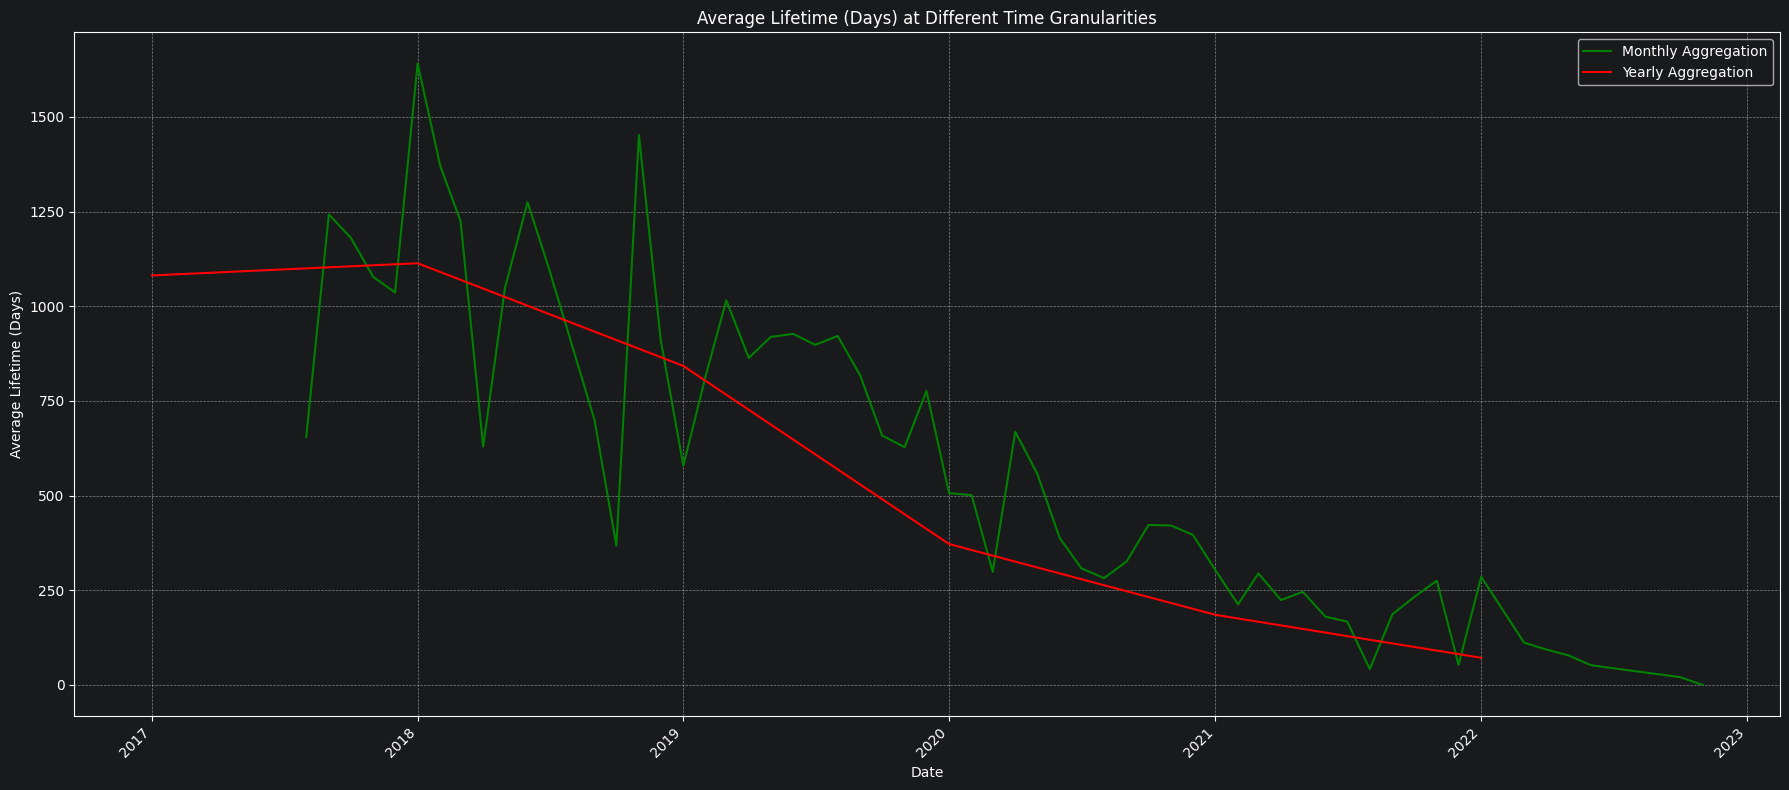

In [16]:
plt.figure(figsize=(18, 8))

# Weekly Lifetime
#sns.lineplot(x='weekly_start', y='days_lifetime', data=weekly_avg_lifetime, label='Weekly Aggregation', color='blue')

# Monthly Lifetime
sns.lineplot(x='monthly_start', y='lifetime_days', data=monthly_avg_lifetime, label='Monthly Aggregation', color='green')

# Yearly Lifetime
sns.lineplot(x='yearly_start', y='lifetime_days', data=yearly_avg_lifetime, label='Yearly Aggregation', color='red')

plt.title('Average Lifetime (Days) at Different Time Granularities')
plt.xlabel('Date')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Lifetime (Days)')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Persistence of Opportunity Triangles

In [17]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_unique_opportunity_persistence_in_minutes`"

opp_persistence = CLIENT.query(query).to_dataframe()

peek_df(opp_persistence)

/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(318201, 11)


,triangle_key,run_id,currencies,run_start,run_end,consecutive_minutes,hour_start,day_start,week_start,month_start,year_start
0,ARN|BTC|ETH,2144,"[ARN, ETH, BTC]",2018-09-04 00:19:00+00:00,2018-09-04 01:02:00+00:00,44,2018-09-04 00,2018-09-04,2018-09-03,2018-09,2018
1,BTC|IOST|USDT,10042,"[BTC, USDT, IOST]",2022-05-09 01:42:00+00:00,2022-05-09 02:06:00+00:00,25,2022-05-09 01,2022-05-09,2022-05-09,2022-05,2022
2,BNB|BTC|LUNA,10,"[BNB, LUNA, BTC]",2022-05-13 00:16:00+00:00,2022-05-13 00:39:00+00:00,24,2022-05-13 00,2022-05-13,2022-05-09,2022-05,2022
3,BTC|EUR|LUNA,12,"[BTC, EUR, LUNA]",2022-05-13 00:16:00+00:00,2022-05-13 00:39:00+00:00,24,2022-05-13 00,2022-05-13,2022-05-09,2022-05,2022
4,BTC|LUNA|USDT,8,"[USDT, LUNA, BTC]",2022-05-13 00:16:00+00:00,2022-05-13 00:39:00+00:00,24,2022-05-13 00,2022-05-13,2022-05-09,2022-05,2022


### Distribution of persistence (in minutes)

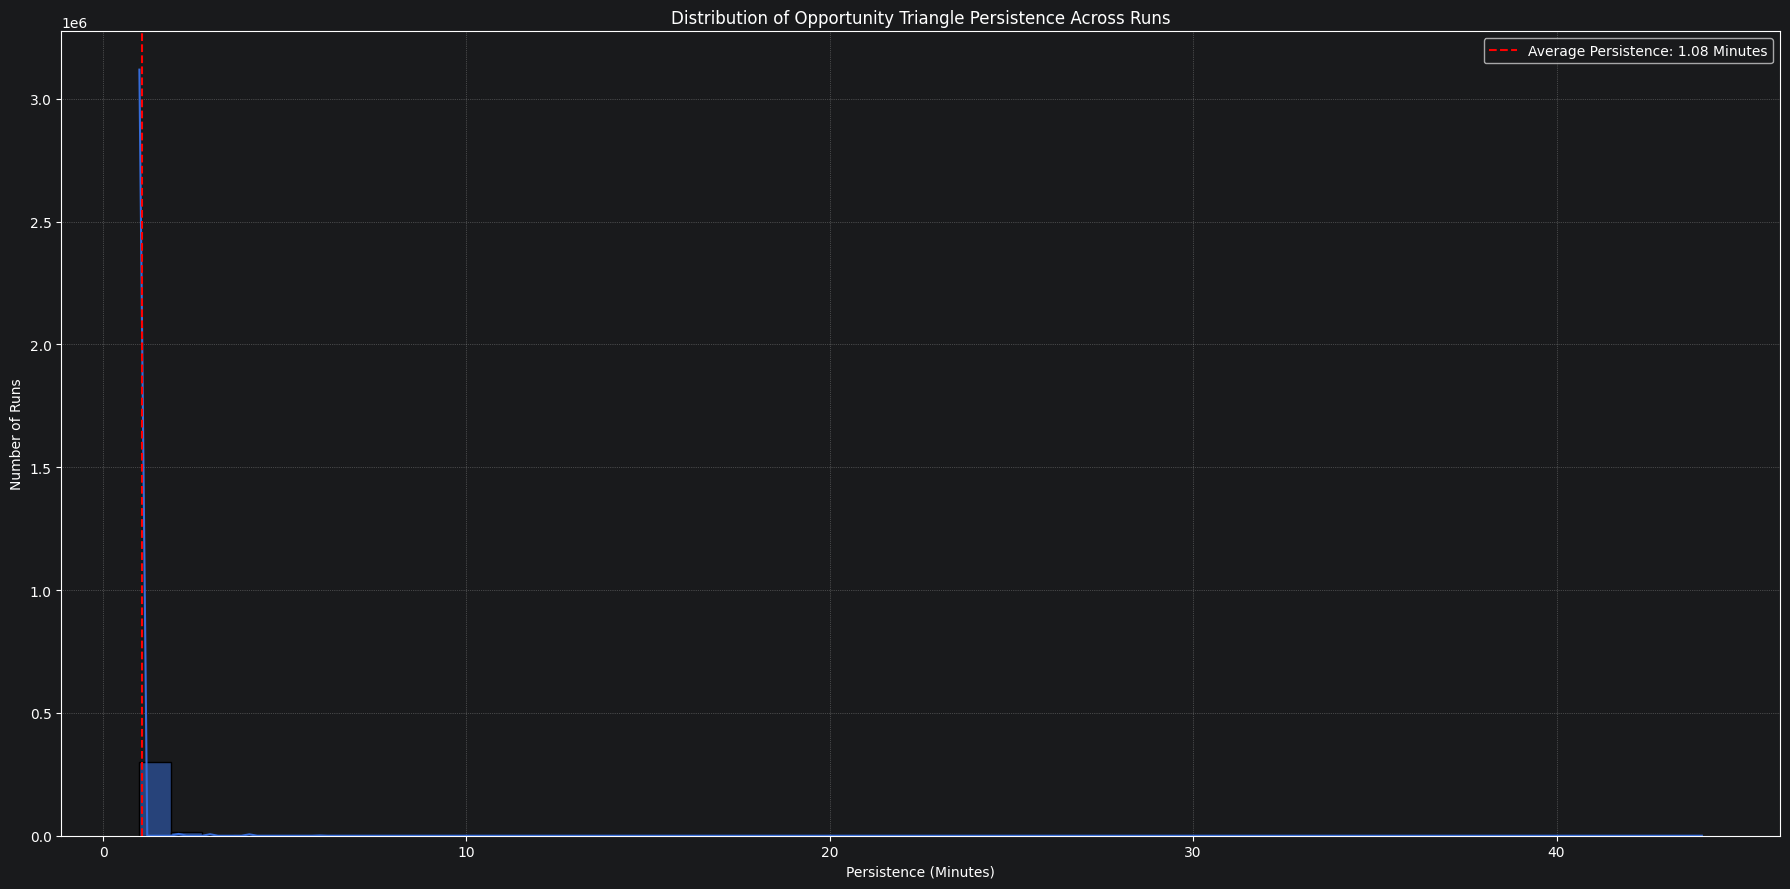

In [18]:
plt.figure(figsize=(18, 9))

sns.histplot(opp_persistence['consecutive_minutes'], bins=50, edgecolor='black', kde=True)

avg_persistence = opp_persistence['consecutive_minutes'].mean()
plt.axvline(avg_persistence, color='red', linestyle='--', label=f'Average Persistence: {avg_persistence:.2f} Minutes')

plt.title('Distribution of Opportunity Triangle Persistence Across Runs')
plt.xlabel('Persistence (Minutes)')
plt.ylabel('Number of Runs')

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Average persistence across time

In [19]:
query = "SELECT * FROM `forward-alchemy-424420-g0.cs6242.vw_unique_opportunity_avg_persistence_in_minutes_by_date`"

opp_avg_persistence_by_date = CLIENT.query(query).to_dataframe()
opp_avg_persistence_by_date['date'] = pd.to_datetime(opp_avg_persistence_by_date['date'], format='mixed', utc=True)

peek_df(opp_persistence)

/Users/alejandro/.local/share/virtualenvs/DVA_Course_Project-989PadqY/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(318201, 11)


,triangle_key,run_id,currencies,run_start,run_end,consecutive_minutes,hour_start,day_start,week_start,month_start,year_start
0,ARN|BTC|ETH,2144,"[ARN, ETH, BTC]",2018-09-04 00:19:00+00:00,2018-09-04 01:02:00+00:00,44,2018-09-04 00,2018-09-04,2018-09-03,2018-09,2018
1,BTC|IOST|USDT,10042,"[BTC, USDT, IOST]",2022-05-09 01:42:00+00:00,2022-05-09 02:06:00+00:00,25,2022-05-09 01,2022-05-09,2022-05-09,2022-05,2022
2,BNB|BTC|LUNA,10,"[BNB, LUNA, BTC]",2022-05-13 00:16:00+00:00,2022-05-13 00:39:00+00:00,24,2022-05-13 00,2022-05-13,2022-05-09,2022-05,2022
3,BTC|EUR|LUNA,12,"[BTC, EUR, LUNA]",2022-05-13 00:16:00+00:00,2022-05-13 00:39:00+00:00,24,2022-05-13 00,2022-05-13,2022-05-09,2022-05,2022
4,BTC|LUNA|USDT,8,"[USDT, LUNA, BTC]",2022-05-13 00:16:00+00:00,2022-05-13 00:39:00+00:00,24,2022-05-13 00,2022-05-13,2022-05-09,2022-05,2022


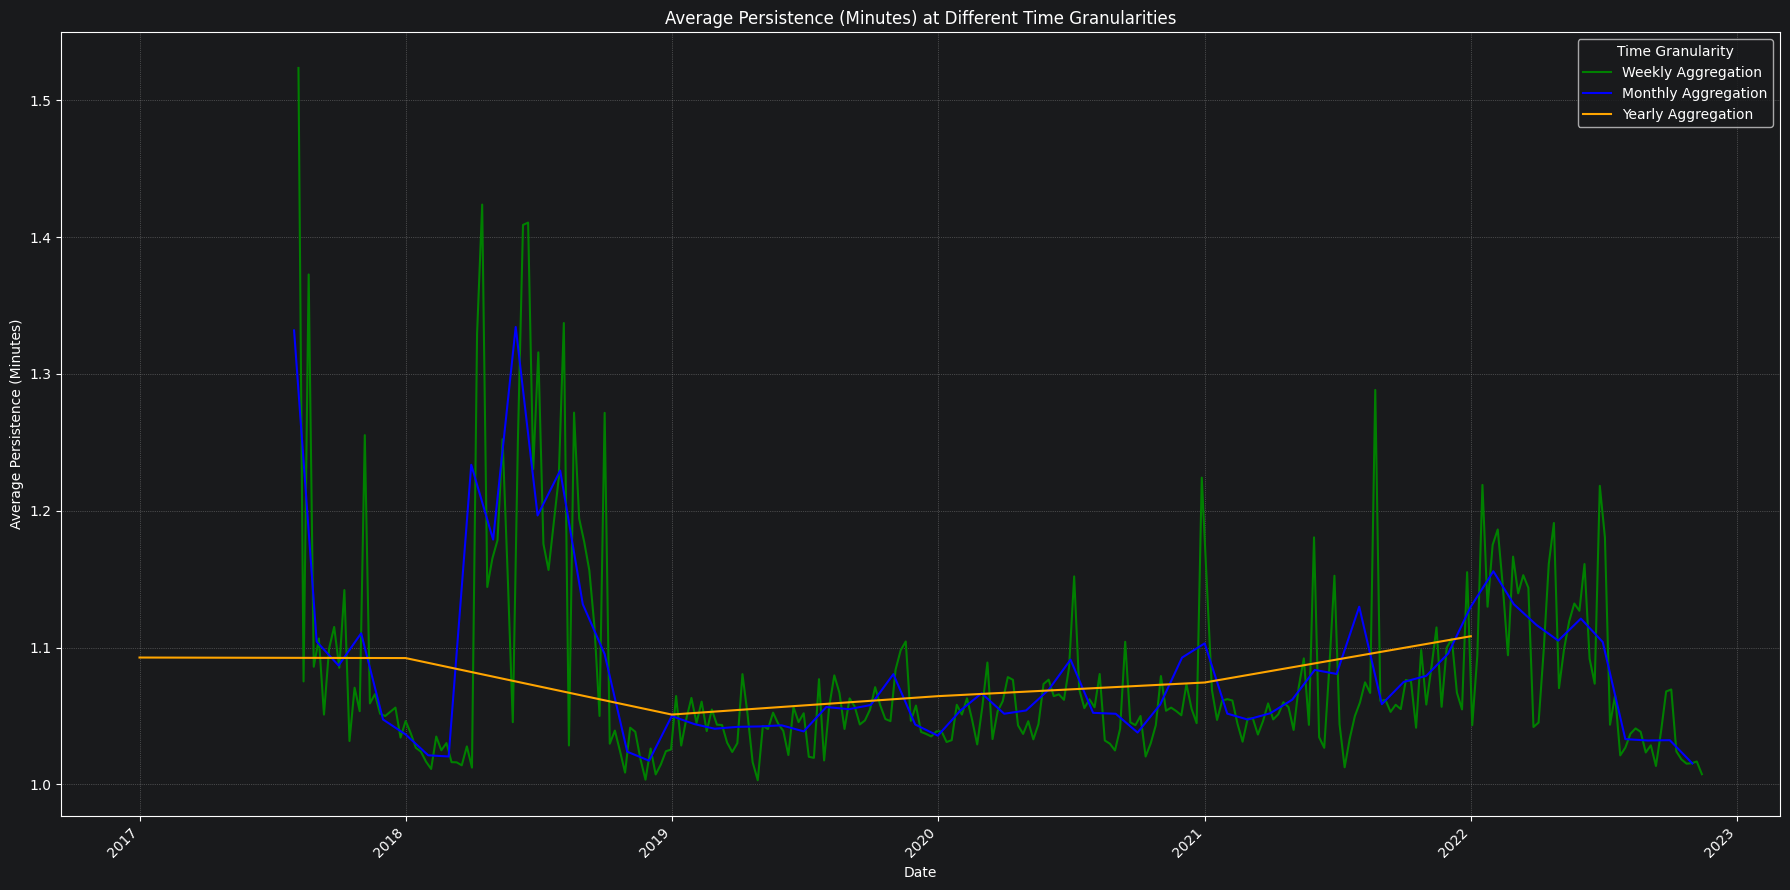

In [20]:
plt.figure(figsize=(18, 9))

# Minute
minute_data = opp_avg_persistence_by_date[opp_avg_persistence_by_date['granularity'] == 'MINUTE']
#sns.lineplot(x='date', y='avg_persistence_minutes', data=minute_data, label='Minutely Aggregation', color='pink')

# Hourly
hour_data = opp_avg_persistence_by_date[opp_avg_persistence_by_date['granularity'] == 'HOUR']
#sns.lineplot(x='date', y='avg_persistence_minutes', data=hour_data, label='Hourly Aggregation', color='purple')

# Daily
day_data = opp_avg_persistence_by_date[opp_avg_persistence_by_date['granularity'] == 'DAY']
#sns.lineplot(x='date', y='avg_persistence_minutes', data=day_data, label='Daily Aggregation', color='red')

# Weekly
week_data = opp_avg_persistence_by_date[opp_avg_persistence_by_date['granularity'] == 'WEEK']
sns.lineplot(x='date', y='avg_persistence_minutes', data=week_data, label='Weekly Aggregation', color='green')

# Monthly
month_data = opp_avg_persistence_by_date[opp_avg_persistence_by_date['granularity'] == 'MONTH']
sns.lineplot(x='date', y='avg_persistence_minutes', data=month_data, label='Monthly Aggregation', color='blue')

# Yearly
year_data = opp_avg_persistence_by_date[opp_avg_persistence_by_date['granularity'] == 'YEAR']
sns.lineplot(x='date', y='avg_persistence_minutes', data=year_data, label='Yearly Aggregation', color='orange')


plt.title('Average Persistence (Minutes) at Different Time Granularities')
plt.xlabel('Date')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Persistence (Minutes)')

plt.legend(title='Time Granularity')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()